# 0.6 — Quarterly Review

Company-wide revenue, profit, margin, and order-volume levels by quarter, Q1 2015 – Q1 2018. Complements [`0.1_company_growth.ipynb`](0.1_company_growth.ipynb) (which covers YoY/QoQ *growth rates* and first identified the Nov 2017+ data artifact) with a levels view across all four metrics together, using the margin definition established in [`0.2_sales_corr.ipynb`](0.2_sales_corr.ipynb) (`profit / Order Item Total`, not `profit / Sales`).

**Metric definitions** (per [[dataco-supply-chain-archive]] convention): Revenue = `Order Item Total` (post-discount), Profit = `Order Profit Per Order`, Margin = Profit / Revenue, Orders = distinct `Order Id`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

CATEGORICAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
BLUE, ORANGE = CATEGORICAL[0], CATEGORICAL[1]
POS, NEG = '#2a78d6', '#e34948'  # diverging pair
INK = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRID = '#e1e0d9'
SURFACE = '#fcfcfb'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'axes.edgecolor': GRID,
    'axes.labelcolor': INK_SECONDARY, 'text.color': INK,
    'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'font.size': 10,
})

def style_axis(ax, x_grid=False, y_grid=True):
    if x_grid: ax.grid(axis='x', zorder=0)
    if y_grid: ax.grid(axis='y', zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)

def usd_m(x, pos=None):
    return f"${x:,.1f}M"

def pct_fmt(v, _):
    return f'{v:.1f}%'

DATA_DIR = '.'
ARTIFACT_START = pd.Timestamp('2017-10-01')  # Nov 2017 order-composition break; Q4 2017 is the first affected quarter

## 1. Load & prep

In [2]:
df = pd.read_csv(f'{DATA_DIR}/DataCoSupplyChainDataset.csv', encoding='latin1')
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])

print(f"{df.shape[0]:,} order lines, {df['order date (DateOrders)'].min().date()} -> {df['order date (DateOrders)'].max().date()}")

180,519 order lines, 2015-01-01 -> 2018-01-31


## 2. Quarterly summary table

In [3]:
quarterly = df.set_index('order date (DateOrders)').resample('QS').agg(
    revenue=('Order Item Total', 'sum'),
    profit=('Order Profit Per Order', 'sum'),
    orders=('Order Id', 'nunique'),
    avg_discount=('Order Item Discount Rate', 'mean'),
    late_risk=('Late_delivery_risk', 'mean'),
)
quarterly['margin_pct'] = quarterly['profit'] / quarterly['revenue'] * 100
quarterly['revenue_per_order'] = quarterly['revenue'] / quarterly['orders']
quarterly['label'] = [f"{d.year} Q{d.quarter}" for d in quarterly.index]
quarterly['artifact_affected'] = quarterly.index >= ARTIFACT_START

quarterly[['label', 'revenue', 'profit', 'margin_pct', 'orders', 'revenue_per_order', 'artifact_affected']].round(2)

,label,revenue,profit,margin_pct,orders,revenue_per_order,artifact_affected
order date (DateOrders),,,,,,,
2015-01-01,2015 Q1,2722444.70,324579.61,11.92,5153,528.32,False
2015-04-01,2015 Q2,2776186.23,330378.74,11.90,5211,532.75,False
2015-07-01,2015 Q3,2772652.03,347071.77,12.52,5231,530.04,False
2015-10-01,2015 Q4,2818260.59,316826.78,11.24,5309,530.85,False
2016-01-01,2016 Q1,2731888.11,294850.43,10.79,5186,526.78,False
2016-04-01,2016 Q2,2726919.15,329888.81,12.10,5159,528.58,False
2016-07-01,2016 Q3,2781996.97,354055.97,12.73,5254,529.50,False
2016-10-01,2016 Q4,2815192.53,331323.86,11.77,5260,535.21,False
2017-01-01,2017 Q1,2759687.34,348643.82,12.63,5141,536.80,False


Q4 2017 onward is flagged `artifact_affected` — every order collapses to a single line item from Nov 2017 (see `0.1_company_growth.ipynb` §2), so `revenue_per_order` in those quarters is not comparable to earlier ones. Profit and margin are ratios of already-realized dollars and units, so they're less distorted by the artifact than revenue-per-order is, but the sharp revenue-per-order drop below is the same underlying break, not a demand change.

## 3. Revenue & profit by quarter

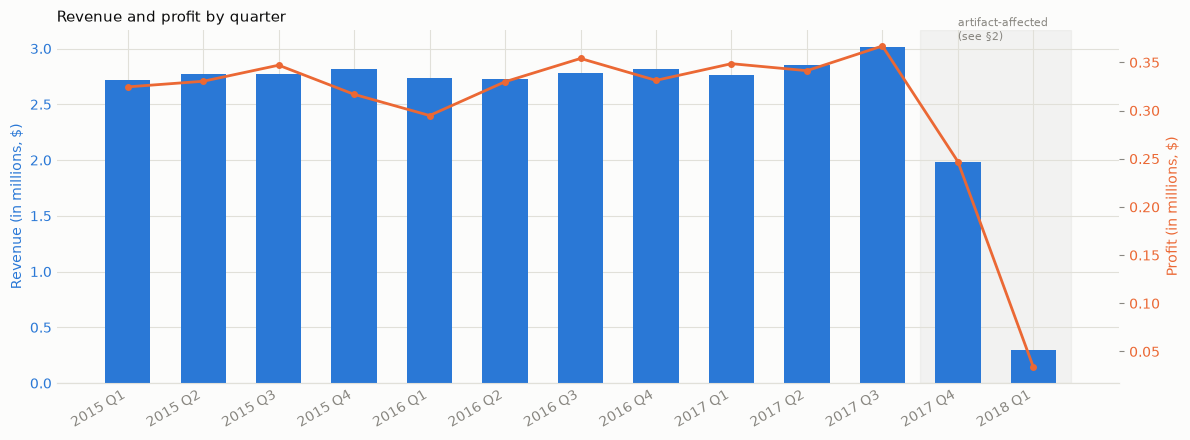

In [4]:
fig, ax = plt.subplots(figsize=(12, 4.5))

x = np.arange(len(quarterly))
rev_m = quarterly['revenue'] / 1e6
profit_m = quarterly['profit'] / 1e6

ax.bar(x, rev_m, color=BLUE, width=0.6, zorder=3, label='Revenue')
ax2 = ax.twinx()
ax2.plot(x, profit_m, color=ORANGE, linewidth=2, marker='o', markersize=4, zorder=4, label='Profit')

artifact_start_idx = quarterly.index.get_loc(quarterly[quarterly['artifact_affected']].index[0])
ax.axvspan(artifact_start_idx - 0.5, len(quarterly) - 0.5, color=INK_MUTED, alpha=0.08, zorder=0)
ax.text(artifact_start_idx, rev_m.max() * 1.02, 'artifact-affected\n(see §2)', ha='left', color=INK_MUTED, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(quarterly['label'], rotation=30, ha='right')
ax.set_ylabel('Revenue (in millions, $)', color=BLUE)
ax2.set_ylabel('Profit (in millions, $)', color=ORANGE)
ax.tick_params(axis='y', labelcolor=BLUE)
ax2.tick_params(axis='y', labelcolor=ORANGE)
ax2.grid(False)
ax.set_title('Revenue and profit by quarter', loc='left', color=INK, fontsize=11)
style_axis(ax)

plt.tight_layout()
plt.show()

## 4. Margin by quarter

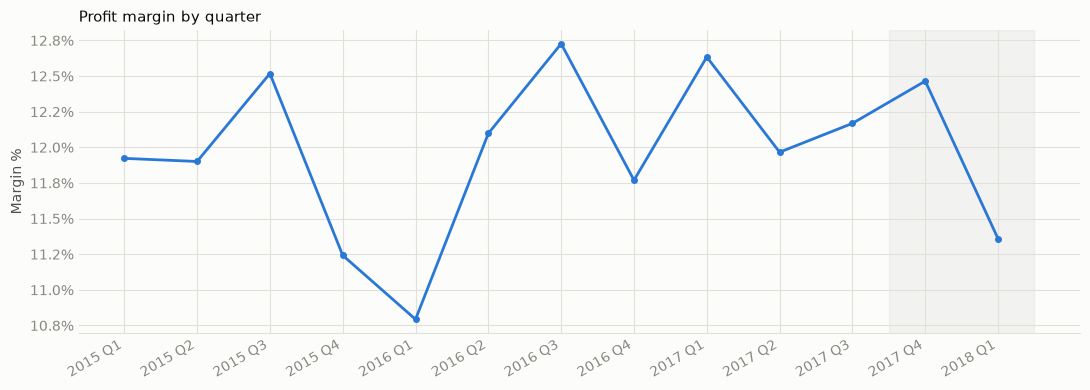

Margin range, Q1 2015 - Q3 2017 (pre-artifact): 10.79% - 12.73%
Margin range, Q4 2017 onward (artifact window): 11.36% - 12.46%


In [5]:
fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(x, quarterly['margin_pct'], color=BLUE, linewidth=2, marker='o', markersize=4, zorder=3)
ax.axvspan(artifact_start_idx - 0.5, len(quarterly) - 0.5, color=INK_MUTED, alpha=0.08, zorder=0)
ax.set_xticks(x)
ax.set_xticklabels(quarterly['label'], rotation=30, ha='right')
ax.set_ylabel('Margin %')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(pct_fmt))
ax.set_title('Profit margin by quarter', loc='left', color=INK, fontsize=11)
style_axis(ax)

plt.tight_layout()
plt.show()

print(f"Margin range, Q1 2015 - Q3 2017 (pre-artifact): {quarterly.loc[~quarterly['artifact_affected'], 'margin_pct'].min():.2f}% - {quarterly.loc[~quarterly['artifact_affected'], 'margin_pct'].max():.2f}%")
print(f"Margin range, Q4 2017 onward (artifact window): {quarterly.loc[quarterly['artifact_affected'], 'margin_pct'].min():.2f}% - {quarterly.loc[quarterly['artifact_affected'], 'margin_pct'].max():.2f}%")

## 5. Order count by quarter

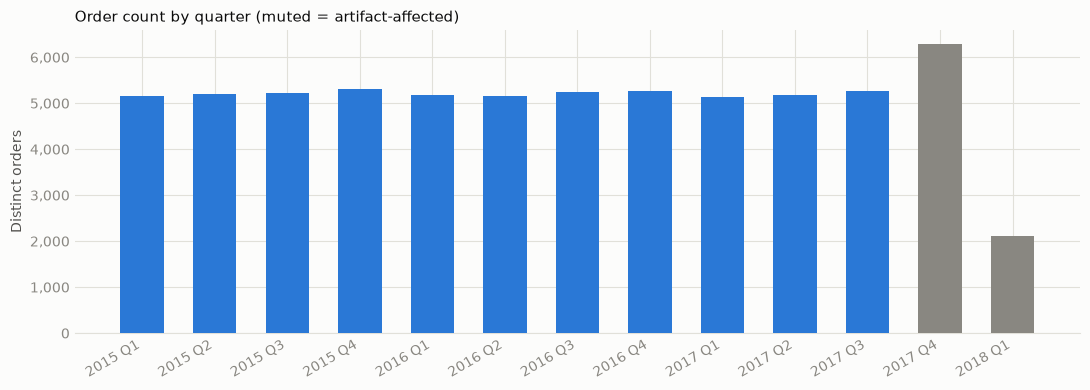

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))

colors = [INK_MUTED if a else BLUE for a in quarterly['artifact_affected']]
ax.bar(x, quarterly['orders'], color=colors, width=0.6, zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(quarterly['label'], rotation=30, ha='right')
ax.set_ylabel('Distinct orders')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.set_title('Order count by quarter (muted = artifact-affected)', loc='left', color=INK, fontsize=11)
style_axis(ax)

plt.tight_layout()
plt.show()

## Takeaways

- **Revenue and profit move together and are level, not growing, through Q3 2017** — the stable ±6% QoQ pattern already found in `0.1_company_growth.ipynb`. The Q4 2017 revenue drop and the much smaller Q1 2018 figure are the order-composition artifact plus a partial month, not a real swing.
- **Margin is remarkably flat across the whole date range**, pre- and post-artifact alike — every quarter lands in a 10.8%-12.7% band, with no visible trend or step change at the Nov 2017 break. Unlike revenue-per-order, margin isn't distorted by the artifact, consistent with orders being split across line items proportionally rather than something that changes the profit-to-revenue ratio.
- **Order counts hold steady around 5,100-5,300/quarter through Q3 2017, then jump to 6,280 in Q4 2017** even as revenue-per-order collapses from ~$530 to ~$316 — confirming (at the company level, not just the regions checked in `0.5.x`) that the artifact is orders being recorded differently, not fewer orders being placed. Q1 2018's low count (2,123) is because the data only covers January, not a decline — it's in line with the other quarters' ~1,700-1,800/month pace.
- **No new anomaly found at quarterly grain.** The region-specific order-flow gaps noted in `0.5_by_region_analysis.ipynb` (e.g. the Jun 2015 - Dec 2016 LATAM dead zone) don't show up here because they're offset by other regions' order flow in the same window — company-wide order volume by quarter has no comparable gap.